In [1]:
import sys

sys.path.append("..")

In [2]:
from src.driver import Driver

Re = 3.4        # ohms
Le = 1.43e-3    # H
Fs = 35.7       # Hz

Qms = 6.62
Qes = 0.36

Mms = 39.5e-3   # kg
Cms = 0.5e-3    # m/N
Sd = 124.7e-4   # m^2

Bl = 9.15       # Tm

driver = Driver(
    Re=Re,
    Le=Le,
    Fs=Fs,
    Qms=Qms,
    Qes=Qes,
    Mms=Mms,
    Cms=Cms,
    Sd=Sd,
    Bl=Bl
)

In [6]:
from src.system import LoudspeakerSystem
import numpy as np

freqs = np.logspace(1, 3, 1000)

free_air = LoudspeakerSystem(driver=driver)
resp = free_air.solve(f = freqs, voltage = 1.0)

Text(0, 0.5, 'Phase (degrees)')

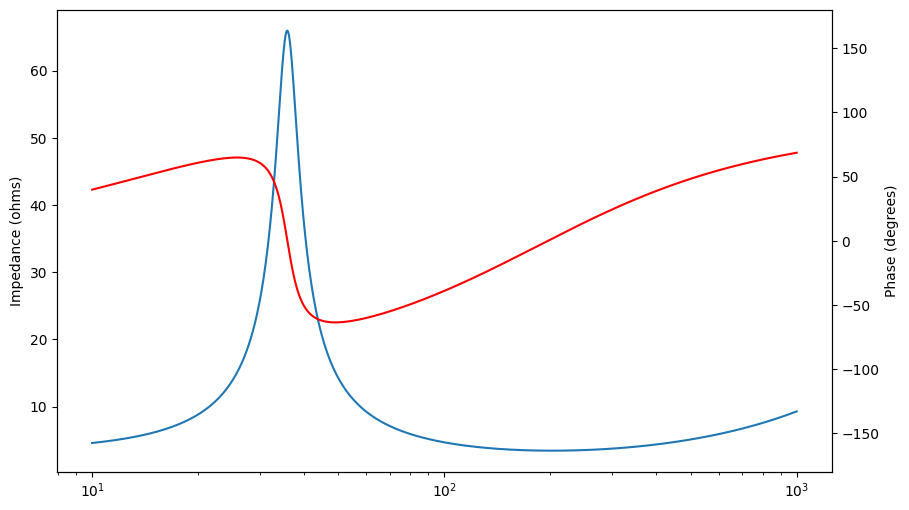

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (10,6))

ax.semilogx(freqs, np.abs(resp.input_impedance))
ax.set_ylabel('Impedance (ohms)')
axx = ax.twinx()
axx.semilogx(freqs, np.angle(resp.input_impedance, deg = True), color='red')
axx.set_ylim([-180,180])
axx.set_ylabel('Phase (degrees)')